In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os

print(os.getcwd())
print(os.listdir())

/
['home', 'usr', '.resolve', 'bin', 'sbin', '.file', 'etc', 'var', 'Library', 'System', '.VolumeIcon.icns', 'private', '.vol', 'Users', 'Applications', 'opt', 'dev', 'Volumes', '.nofollow', 'tmp', 'cores']


In [5]:
import os

os.chdir("/Users/ashwinsathishkumar/Downloads")

print(os.getcwd())
print(os.listdir()[:20])

/Users/ashwinsathishkumar/Downloads
['anydesk.dmg', 'DI_Summary.pdf', 'ezgif-10b7b860ecd9ca7f-jpg', 'A Message of Faith and Service.png', 'IMG_0786.HEIC', 'googlechrome.dmg', 'llm25aug-1.pdf', 'Sequence_cinematic_product_1080p_20260214110.mp4', 'demo_simulation.py', ' .mp4', 'PG_ResearchMethodology_Report_AY25_26_V1.pdf', 'Notion-6.3.2-universal.dmg', 'CSP_5221_FSML_Case_Study.pdf', 'Student Receipt.pdf', 'Lecture__Notes 2', 'ChatGPT Image Apr 9, 2026 at 12_18_52 PM.png', 'Project Report-2.docx', 'Decision_Intelligence.mp4', 'paper_draft.docx', 'IMG_9876.HEIC']


In [6]:
import glob

print(glob.glob("*Bengaluru*"))
print(glob.glob("*.csv*"))
print(glob.glob("*.xls*"))

['Bengaluru_Sakleshpur_Road_Trip.pdf', 'Bengaluru_House_Data.csv.xls']
['Emotion_classify_Data.csv', 'text_to_csv_columns.csv', 'Bengaluru_House_Data.csv.xls', 'Untitled spreadsheet - Sheet1.csv']
['MAHE Vendor registration blank.xlsx', 'Literature Survey on AI-Driven Market Validation and Behavioral Modeling.xlsx', 'TN_Election_Model.xlsx', 'Final_TN_Prediction.xlsx', 'CSP5233_Lesson_Plan.xlsx', 'Bengaluru_House_Data.csv.xls']


In [7]:
import pandas as pd

df = pd.read_csv("Bengaluru_House_Data.csv.xls")

print(df.shape)
df.head()

(13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [8]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nSummary Statistics:")
print(df.describe())

Shape: (13320, 9)

Missing Values:
society         5502
balcony          609
bath              73
size              16
location           1
area_type          0
availability       0
total_sqft         0
price              0
dtype: int64

Summary Statistics:
               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


In [9]:
top_locations = df.groupby("location")["price"]\
.mean()\
.sort_values(ascending=False)\
.head(10)

print(top_locations)

location
Cubbon Road            1900.000000
Ashok Nagar            1486.000000
Defence Colony         1167.714286
Yemlur                 1093.388889
Church Street          1068.000000
D Souza Layout         1015.000000
Sadashiva Nagar        1011.100000
Sindhi Colony           988.000000
Srinivas Colony         922.000000
5th Block Jayanagar     905.000000
Name: price, dtype: float64


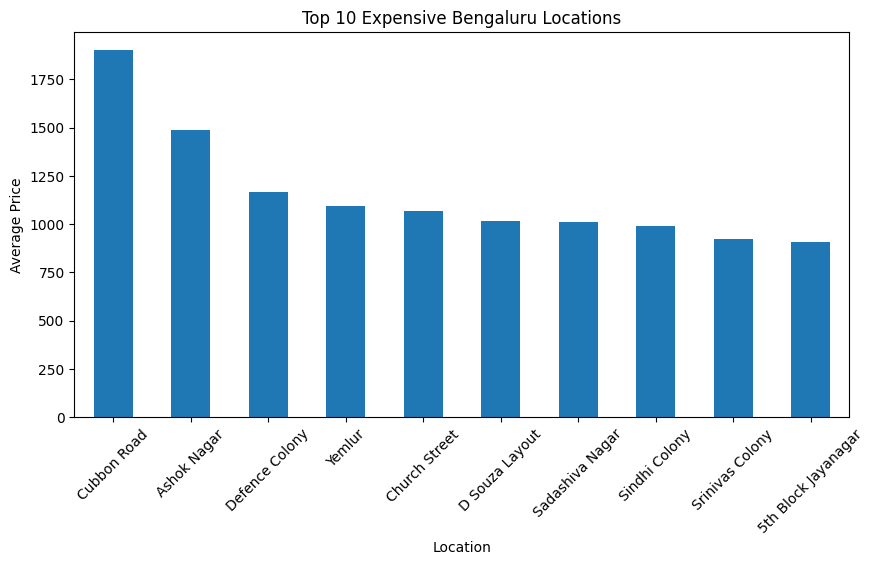

In [10]:
import matplotlib.pyplot as plt

top_locations.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Expensive Bengaluru Locations")
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.show()

In [11]:
df2 = df.copy()

df2.drop(columns=['society'], inplace=True)

df2['balcony'] = df2['balcony'].fillna(df2['balcony'].median())
df2['bath'] = df2['bath'].fillna(df2['bath'].median())

df2.dropna(inplace=True)

print(df2.isnull().sum())
print(df2.shape)

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64
(13303, 8)


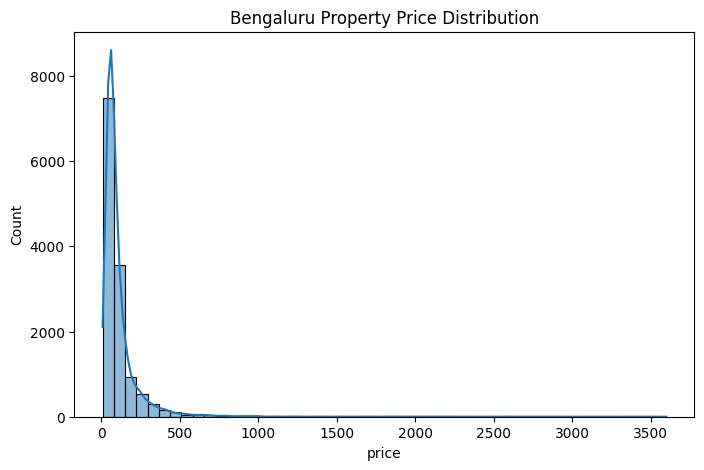

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df2['price'], bins=50, kde=True)

plt.title("Bengaluru Property Price Distribution")

plt.show()

In [13]:
df2.groupby('size')['price']\
.mean()\
.sort_values(ascending=False)\
.head(15)

size
43 Bedroom    660.000000
10 Bedroom    561.250000
16 BHK        550.000000
19 BHK        490.000000
5 BHK         425.618644
7 BHK         389.294118
10 BHK        342.500000
12 Bedroom    300.000000
4 BHK         278.415220
13 BHK        275.000000
4 Bedroom     265.067379
11 BHK        255.000000
5 Bedroom     252.929293
9 BHK         248.250000
9 Bedroom     240.847826
Name: price, dtype: float64

In [14]:
top_area_count = df2['location'].value_counts().head(10)

print(top_area_count)

location
Whitefield               539
Sarjapur  Road           397
Electronic City          302
Kanakpura Road           273
Thanisandra              234
Yelahanka                212
Uttarahalli              186
Hebbal                   177
Marathahalli             175
Raja Rajeshwari Nagar    171
Name: count, dtype: int64


In [15]:
df2['BHK'] = df2['size'].apply(lambda x: int(x.split(' ')[0]))

print(df2['BHK'].value_counts().sort_index())

BHK
1      656
2     5528
3     4856
4     1417
5      356
6      221
7      100
8       89
9       54
10      14
11       4
12       1
13       1
14       1
16       1
18       1
19       1
27       1
43       1
Name: count, dtype: int64


In [16]:
df3 = df2[df2['BHK'] <= 10]

print(df3.shape)

(13291, 9)


In [17]:
bhk_price = df3.groupby('BHK')['price'].mean()

print(bhk_price)

BHK
1      44.633415
2      59.579211
3     110.957464
4     270.634474
5     281.549157
6     223.927602
7     244.370000
8     207.550562
9     241.944444
10    530.000000
Name: price, dtype: float64


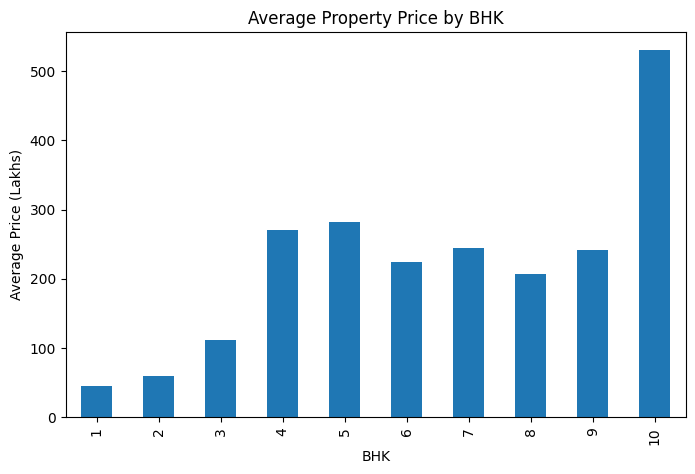

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bhk_price.plot(kind='bar')

plt.title("Average Property Price by BHK")

plt.xlabel("BHK")

plt.ylabel("Average Price (Lakhs)")

plt.show()

In [19]:
df3['total_sqft'] = pd.to_numeric(df3['total_sqft'], errors='coerce')

df3['price_per_sqft'] = (df3['price']*100000)/df3['total_sqft']

print(df3[['location','BHK','price','price_per_sqft']].head())

                   location  BHK   price  price_per_sqft
0  Electronic City Phase II    2   39.07     3699.810606
1          Chikka Tirupathi    4  120.00     4615.384615
2               Uttarahalli    3   62.00     4305.555556
3        Lingadheeranahalli    3   95.00     6245.890861
4                  Kothanur    2   51.00     4250.000000


/var/folders/k8/h0p3n3zs1s32mljsjlmlf_rw0000gn/T/ipykernel_4640/770650588.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['total_sqft'] = pd.to_numeric(df3['total_sqft'], errors='coerce')
/var/folders/k8/h0p3n3zs1s32mljsjlmlf_rw0000gn/T/ipykernel_4640/770650588.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['price_per_sqft'] = (df3['price']*100000)/df3['total_sqft']


In [20]:
df3 = df3.copy()

df3.loc[:, 'total_sqft'] = pd.to_numeric(
    df3['total_sqft'],
    errors='coerce'
)

df3.loc[:, 'price_per_sqft'] = (
    df3['price']*100000
)/df3['total_sqft']

df3.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,BHK,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2,4250.000000


In [21]:
premium_locations = df3.groupby('location')[
    'price_per_sqft'
].mean().sort_values(
    ascending=False
).head(10)

print(premium_locations)

location
Grihalakshmi Layout                 625000.000000
Srirampuram                         481004.144004
Suragajakkanahalli                  339363.636364
Weavers Colony                       68801.313629
Raghuvanahalli                       38647.926429
Sarjapur  Road                       37205.230866
Cubbon Road                          35042.419771
Sector 3 HSR Layout                  31666.666667
Hsr layout sector3                   31250.000000
J P Nagar 7th Phase Ramayya City     29166.666667
Name: price_per_sqft, dtype: float64


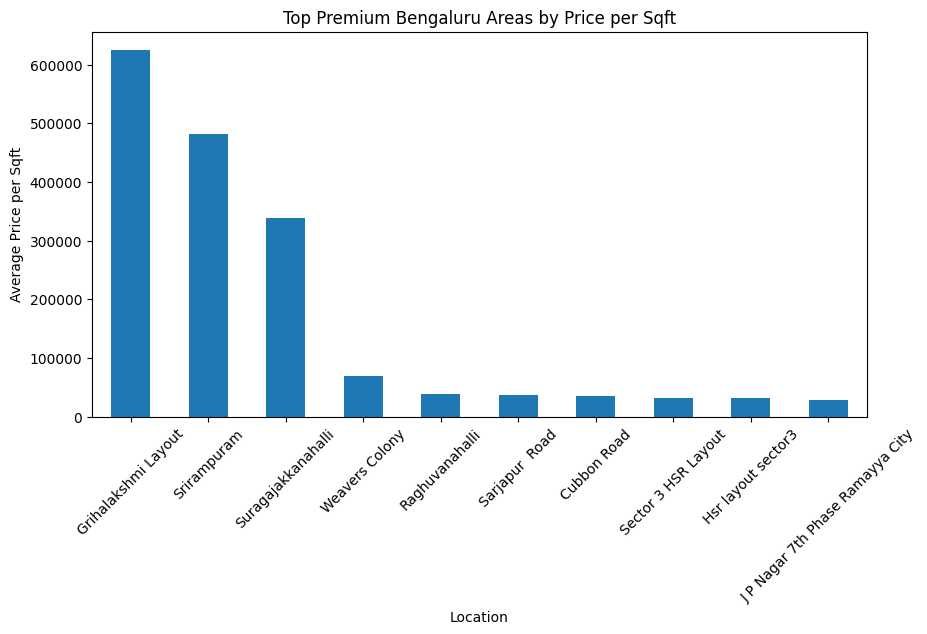

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

premium_locations.plot(kind='bar')

plt.title("Top Premium Bengaluru Areas by Price per Sqft")

plt.xlabel("Location")
plt.ylabel("Average Price per Sqft")

plt.xticks(rotation=45)

plt.show()

In [23]:
print(df3['price_per_sqft'].describe())

count    1.305200e+04
mean     7.948060e+03
std      1.073298e+05
min      2.678298e+02
25%      4.266434e+03
50%      5.454545e+03
75%      7.335633e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64


In [24]:
df4 = df3[
    (df3['price_per_sqft'] > 1000) &
    (df3['price_per_sqft'] < 30000)
]

print(df4.shape)

(12994, 10)


In [25]:
premium_clean = df4.groupby('location')[
    'price_per_sqft'
].mean().sort_values(
    ascending=False
).head(10)

print(premium_clean)


location
J P Nagar 7th Phase Ramayya City     29166.666667
Sector 4 HSR Layout                  29166.666667
Vittal Mallya Road                   29126.213592
1A Block Koramangala                 27542.372881
BEML Layout 5th Stage                27083.333333
Beml layout, Rajarajeshwari nagar    27083.333333
Old Town                             26666.666667
Indiranagar HAL 2nd Stage            26666.666667
Xavier Layout                        26246.719160
Geetanjali Layout                    25000.000000
Name: price_per_sqft, dtype: float64


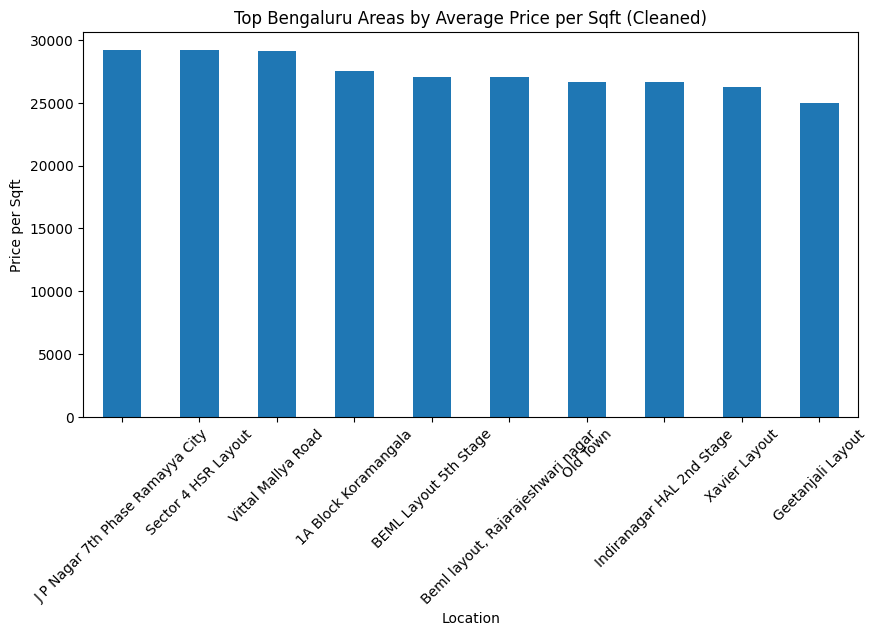

In [26]:
plt.figure(figsize=(10,5))

premium_clean.plot(kind='bar')

plt.title(
    "Top Bengaluru Areas by Average Price per Sqft (Cleaned)"
)

plt.xlabel("Location")
plt.ylabel("Price per Sqft")

plt.xticks(rotation=45)

plt.show()

In [27]:
premium_clean = df4.groupby(
    'location'
)['price_per_sqft'].mean()\
.sort_values(
    ascending=False
).head(10)

print(premium_clean)

location
J P Nagar 7th Phase Ramayya City     29166.666667
Sector 4 HSR Layout                  29166.666667
Vittal Mallya Road                   29126.213592
1A Block Koramangala                 27542.372881
BEML Layout 5th Stage                27083.333333
Beml layout, Rajarajeshwari nagar    27083.333333
Old Town                             26666.666667
Indiranagar HAL 2nd Stage            26666.666667
Xavier Layout                        26246.719160
Geetanjali Layout                    25000.000000
Name: price_per_sqft, dtype: float64


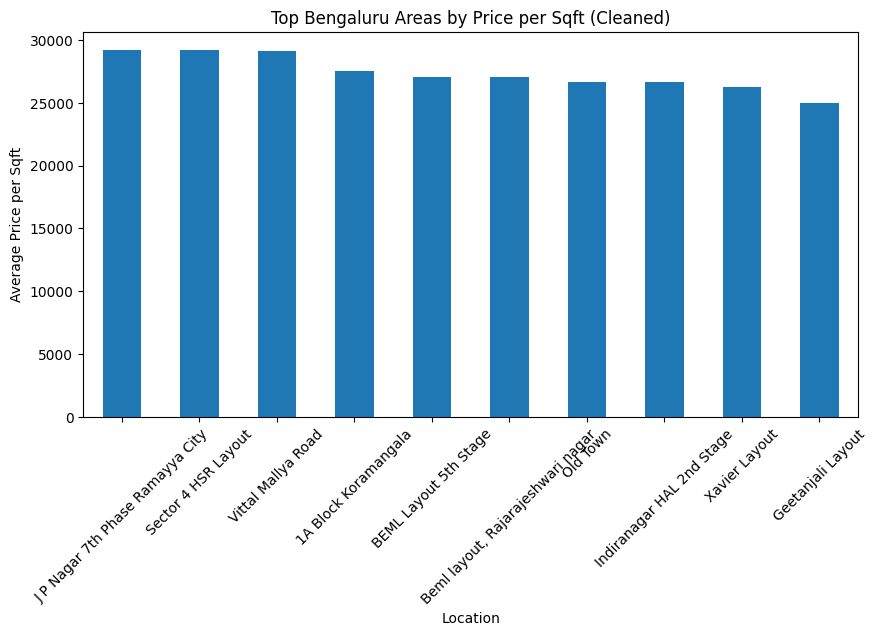

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

premium_clean.plot(
    kind='bar'
)

plt.title(
    "Top Bengaluru Areas by Price per Sqft (Cleaned)"
)

plt.xlabel("Location")

plt.ylabel(
    "Average Price per Sqft"
)

plt.xticks(
    rotation=45
)

plt.show()

In [29]:
affordable = df4.groupby(
    'location'
)['price_per_sqft'].mean()\
.sort_values(
    ascending=True
).head(10)

print(affordable)

location
Indranagar  100ft road defence colony    1379.310345
Yelahanka,MVIT college                   1495.513460
Sadhguru Layout                          2149.277061
BAGUR                                    2478.134111
BDS Layout                               2500.000000
Handenahalli                             2526.315789
Phase 1 Kammasandra                      2548.025546
Sir M V Nagar                            2727.272727
Madanayakahalli                          2833.333333
Tunganagara                              2866.701102
Name: price_per_sqft, dtype: float64


In [30]:
avg_price = round(df4['price'].mean(),2)

median_price = round(df4['price'].median(),2)

avg_sqft = round(df4['total_sqft'].mean(),2)

avg_pps = round(df4['price_per_sqft'].mean(),2)

print("Average Price:", avg_price)

print("Median Price:", median_price)

print("Average Sqft:", avg_sqft)

print("Average Price/Sqft:", avg_pps)

Average Price: 109.38
Median Price: 71.3
Average Sqft: 1534.4
Average Price/Sqft: 6596.02


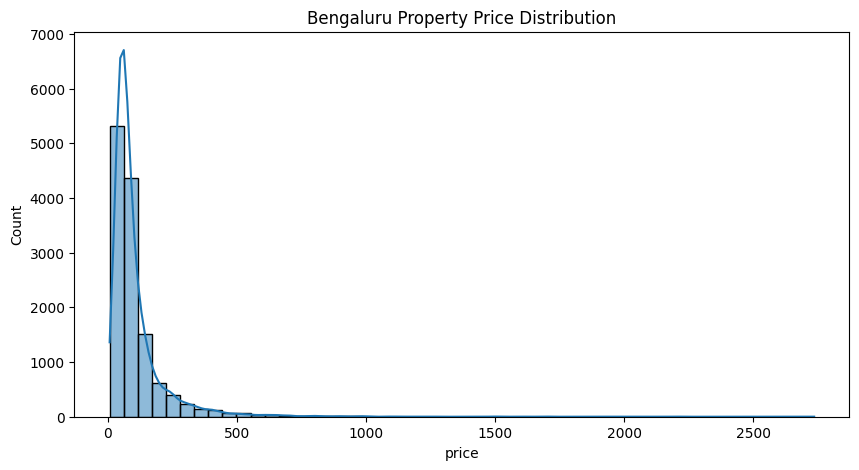

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(
    df4['price'],
    bins=50,
    kde=True
)

plt.title(
    "Bengaluru Property Price Distribution"
)

plt.show()

In [32]:
summary = pd.DataFrame({

'Metric':[
'Average Price',
'Median Price',
'Average Sqft',
'Average Price per Sqft'
],

'Value':[
avg_price,
median_price,
avg_sqft,
avg_pps
]

})

summary

,Metric,Value
0,Average Price,109.38
1,Median Price,71.30
2,Average Sqft,1534.40
3,Average Price per Sqft,6596.02


In [33]:
df4.to_csv(
    "bengaluru_cleaned_data.csv",
    index=False
)

print("Clean dataset exported 🚀")


Clean dataset exported 🚀


In [34]:
df4.to_csv(
    "bengaluru_cleaned_data.csv",
    index=False
)

print("Export successful 🚀")

Export successful 🚀


In [35]:
import sqlite3

conn = sqlite3.connect(
    "bengaluru_housing.db"
)

df4.to_sql(
    "housing",
    conn,
    if_exists='replace',
    index=False
)

print("Database created 🚀")

Database created 🚀


In [36]:
query = """

SELECT location,
ROUND(
AVG(price_per_sqft),2
) AS avg_price_sqft

FROM housing

GROUP BY location

ORDER BY avg_price_sqft DESC

LIMIT 10;

"""

pd.read_sql_query(
    query,
    conn
)

,location,avg_price_sqft
0,Sector 4 HSR Layout,29166.67
1,J P Nagar 7th Phase Ramayya City,29166.67
2,Vittal Mallya Road,29126.21
3,1A Block Koramangala,27542.37
4,"Beml layout, Rajarajeshwari nagar",27083.33
5,BEML Layout 5th Stage,27083.33
6,Old Town,26666.67
7,Indiranagar HAL 2nd Stage,26666.67
8,Xavier Layout,26246.72
9,Geetanjali Layout,25000.00
